# **Laboratorio 8: Ready, Set, Deploy! 👩‍🚀👨‍🚀**

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Otoño 2026 </strong></center>

### Cuerpo Docente:

- Profesores: Pablo Badilla, Diego Cortez
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Bryan Cabezas
- Nombre de alumno 2: Gonzalo Sobarzo

### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/BAFCS/MDS7202)

## Temas a tratar

- Entrenamiento y registro de modelos usando MLFlow.
- Despliegue de modelo usando FastAPI
- Containerización del proyecto usando Docker

### Objetivos principales del laboratorio

- Generar una solución a un problema a partir de ML
- Desplegar su solución usando MLFlow, FastAPI y Docker

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre DataFrames.

# **Introducción**

<p align="center">
  <img src="https://media.giphy.com/media/v1.Y2lkPTc5MGI3NjExODJnMHJzNzlkNmQweXoyY3ltbnZ2ZDlxY2c0aW5jcHNzeDNtOXBsdCZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/AbPdhwsMgjMjax5reo/giphy.gif" width="400">
</p>



Consumida en la tristeza el despido de Renacín, Smapina ha decaído en su desempeño, lo que se ha traducido en un irregular tratamiento del agua. Esto ha implicado una baja en la calidad del agua, llegando a haber algunos puntos de la comuna en la que el vital elemento no es apto para el consumo humano. Es por esto que la sanitaria pública de la municipalidad de Maipú se ha contactado con ustedes para que le entreguen una urgente solución a este problema (a la vez que dejan a Smapina, al igual que Renacín, sin trabajo 😔).

El problema que la empresa le ha solicitado resolver es el de elaborar un sistema que les permita saber si el agua es potable o no. Para esto, la sanitaria les ha proveido una base de datos con la lectura de múltiples sensores IOT colocados en diversas cañerías, conductos y estanques. Estos sensores señalan nueve tipos de mediciones químicas y más una etiqueta elaborada en laboratorio que indica si el agua es potable o no el agua.

La idea final es que puedan, en el caso que el agua no sea potable, dar un aviso inmediato para corregir el problema. Tenga en cuenta que parte del equipo docente vive en Maipú y su intoxicación podría implicar graves problemas para el cierre del curso.

Atributos:

1. pH value
2. Hardness
3. Solids (Total dissolved solids - TDS)
4. Chloramines
5. Sulfate
6. Conductivity
7. Organic_carbon
8. Trihalomethanes
9. Turbidity

Variable a predecir:

10. Potability (1 si es potable, 0 no potable)

Descripción de cada atributo se pueden encontrar en el siguiente link: [dataset](https://www.kaggle.com/adityakadiwal/water-potability)

# **1. Optimización de modelos con Optuna + MLFlow (2.0 puntos)**

El objetivo de esta sección es que ustedes puedan combinar Optuna con MLFlow para poder realizar la optimización de los hiperparámetros de sus modelos.

Como aún no hemos hablado nada sobre `MLFlow` cabe preguntarse: **¡¿Qué !"#@ es `MLflow`?!**

<p align="center">
  <img src="https://media.tenor.com/eusgDKT4smQAAAAC/matthew-perry-chandler-bing.gif" width="400">
</p>

## **MLFlow**

`MLflow` es una plataforma de código abierto que simplifica la gestión y seguimiento de proyectos de aprendizaje automático. Con sus herramientas, los desarrolladores pueden organizar, rastrear y comparar experimentos, además de registrar modelos y controlar versiones.

<p align="center">
  <img src="https://spark.apache.org/images/mlflow-logo.png" width="350">
</p>

Si bien esta plataforma cuenta con un gran número de herramientas y funcionalidades, en este laboratorio trabajaremos con dos:
1. **Runs**: Registro que constituye la información guardada tras la ejecución de un entrenamiento. Cada `run` tiene su propio run_id, el cual sirve como identificador para el entrenamiento en sí mismo. Dentro de cada `run` podremos acceder a información como los hiperparámetros utilizados, las métricas obtenidas, las librerías requeridas y hasta nos permite descargar el modelo entrenado.
2. **Experiments**: Se utilizan para agrupar y organizar diferentes ejecuciones de modelos (`runs`). En ese sentido, un experimento puede agrupar 1 o más `runs`. De esta manera, es posible también registrar métricas, parámetros y archivos (artefactos) asociados a cada experimento.

### **Todo bien pero entonces, ¿cómo se usa en la práctica `MLflow`?**

Es sencillo! Considerando un problema de machine learning genérico, podemos registrar la información relevante del entrenamiento ejecutando `mlflow.autolog()` antes entrenar nuestro modelo. Veamos este bonito ejemplo facilitado por los mismos creadores de `MLflow`:

```python
#!pip install mlflow
import mlflow # importar mlflow

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor

db = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(db.data, db.target)

# Create and train models.
rf = RandomForestRegressor(n_estimators=100, max_depth=6, max_features=3)

mlflow.autolog() # registrar automáticamente información del entrenamiento
with mlflow.start_run(): # delimita inicio y fin del run
    # aquí comienza el run
    rf.fit(X_train, y_train) # train the model
    predictions = rf.predict(X_test) # Use the model to make predictions on the test dataset.
    # aquí termina el run
```

Si ustedes ejecutan el código anterior en sus máquinas locales (desde un jupyter notebook por ejemplo) se darán cuenta que en su directorio *root* se ha creado la carpeta `mlruns`. Esta carpeta lleva el tracking de todos los entrenamientos ejecutados desde el directorio root (importante: si se cambian de directorio y vuelven a ejecutar el código anterior, se creará otra carpeta y no tendrán acceso al entrenamiento anterior). Para visualizar estos entrenamientos, `MLflow` nos facilita hermosa interfaz visual a la que podemos acceder ejecutando:

```
mlflow ui
```

y luego pinchando en la ruta http://127.0.0.1:5000 que nos retorna la terminal. Veamos en vivo algunas de sus funcionalidades!

<p align="center">
  <img src="https://media4.giphy.com/media/v1.Y2lkPTc5MGI3NjExZXVuM3A5MW1heDFpa21qbGlwN2pyc2VoNnZsMmRzODZxdnluemo2bCZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/3o84sq21TxDH6PyYms/giphy.gif" width="400">
</p>

Les dejamos también algunos comandos útiles:

- `mlflow.create_experiment("nombre_experimento")`: Les permite crear un nuevo experimento para agrupar entrenamientos
- `mlflow.log_metric("nombre_métrica", métrica)`: Les permite registrar una métrica *custom* bajo el nombre de "nombre_métrica"


In [1]:
!uv add mlflow

Resolved 176 packages in 17ms
⠙ Preparing packages... (0/2)                                                   
⠙ Preparing packages... (0/2)-------------------     0 B/158.33 KiB          
⠙ Preparing packages... (0/2)-------------------     0 B/158.33 KiB          
protobuf             ------------------------------     0 B/158.33 KiB
⠙ Preparing packages... (0/2)-------------------     0 B/1.01 MiB            
protobuf             ------------------------------ 16.00 KiB/158.33 KiB
⠙ Preparing packages... (0/2)-------------------     0 B/1.01 MiB            
protobuf             ------------------------------ 16.00 KiB/158.33 KiB
⠙ Preparing packages... (0/2)------------------- 14.81 KiB/1.01 MiB          
protobuf             ------------------------------ 32.00 KiB/158.33 KiB
⠙ Preparing packages... (0/2)------------------- 14.81 KiB/1.01 MiB          
protobuf             ------------------------------ 43.69 KiB/158.33 KiB
⠙ Preparing packages... (0/2)------------------- 14.81 KiB

Si tiene problemas puede necesitar ejecutar `uv add "setuptools<82.0.0"`

In [2]:
import pandas as pd
import mlflow # importar mlflow
import mlflow.sklearn

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestRegressor

import pickle
import optuna
import os

from xgboost import XGBClassifier
from sklearn.metrics import f1_score


/Users/bryan/Desktop/MDS/segundo semestre/Laboratorio de ciencia de datos/Repo/MDS7202/.venv/lib/python3.14/site-packages/mlflow/utils/autologging_utils/versioning.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/Users/bryan/Desktop/MDS/segundo semestre/Laboratorio de ciencia de datos/Repo/MDS7202/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
db = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(db.data, db.target)

# Create and train models.
rf = RandomForestRegressor(n_estimators=100, max_depth=6, max_features=3)

mlflow.autolog() # registrar automáticamente información del entrenamiento
with mlflow.start_run(): # delimita inicio y fin del run
    # aquí comienza el run
    rf.fit(X_train, y_train) # train the model
    predictions = rf.predict(X_test) # Use the model to make predictions on the test dataset.
    # aquí termina el run

2026/06/06 17:56:32 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


In [10]:
run = mlflow.last_active_run()
info = mlflow.get_run(run.info.run_id)
print(info.data.params)
print(info.data.metrics)

{'bootstrap': 'True', 'ccp_alpha': '0.0', 'criterion': 'squared_error', 'max_depth': '6', 'max_features': '3', 'max_leaf_nodes': 'None', 'max_samples': 'None', 'min_impurity_decrease': '0.0', 'min_samples_leaf': '1', 'min_samples_split': '2', 'min_weight_fraction_leaf': '0.0', 'monotonic_cst': 'None', 'n_estimators': '100', 'n_jobs': 'None', 'oob_score': 'False', 'random_state': 'None', 'verbose': '0', 'warm_start': 'False'}
{'training_mae': 30.028636967253405, 'training_mse': 1306.40582889751, 'training_r2_score': 0.7782825644533835, 'training_rmse': 36.14423645475873, 'training_score': 0.7782825644533835}


## **1.1 Combinando Optuna + MLflow (2.0 puntos)**

Ahora que tenemos conocimiento de ambas herramientas, intentemos ahora combinarlas para **más sabor**. El objetivo de este apartado es simple: automatizar la optimización de los parámetros de nuestros modelos usando `Optuna` y registrando de forma automática cada resultado en `MLFlow`.

Considerando el objetivo planteado, se le pide completar la función `optimize_model`, la cual debe:
- **Optimizar los hiperparámetros del modelo `XGBoost` usando `Optuna`.** Realice una cantidad de iteraciones para evitar tiempos de ejecución excesivos (al menos 10)
- **Registrar cada entrenamiento en un experimento nuevo**, asegurándose de que la métrica `f1-score` se registre como `"valid_f1"`. No se deben guardar todos los experimentos en *Default*; en su lugar, cada `experiment` y `run` deben tener nombres interpretables, reconocibles y diferentes a los nombres por defecto (por ejemplo, para un run: "XGBoost con lr 0.1").
- **Devolver el mejor modelo** usando la función `get_best_model` y serializarlo en el disco con `pickle.dump`. Luego, guardar el modelo en la carpeta `/models`.
- **Guardar el código en `optimize.py`**. La ejecución de `python optimize.py` debería ejecutar la función `optimize_model`.
- **Guardar las versiones de las librerías utilizadas** en el desarrollo.

*Hint: Le puede ser útil revisar los parámetros que recibe `mlflow.start_run`*

```python
def get_best_model(experiment_id):
    runs = mlflow.search_runs(experiment_id)
    best_model_id = runs.sort_values("metrics.valid_f1")["run_id"].iloc[0]
    best_model = mlflow.sklearn.load_model("runs:/" + best_model_id + "/model")

    return best_model
```

In [ ]:
#def get_best_model(experiment_id):
#    runs = mlflow.search_runs(experiment_id)
#    best_model_id = runs.sort_values("metrics.valid_f1")["run_id"].iloc[0]
#    best_model = mlflow.sklearn.load_model("runs:/" + best_model_id + "/model")#

#    return best_model

In [ ]:
def get_best_model(experiment_id):
    runs = mlflow.search_runs(experiment_ids=[experiment_id]) #Se pasa la ID dentro de una lista a experiments_ids porque esta función espera una lista de IDs de experimentos, incluso si solo se está buscando en uno. Esto es necesario para que la función pueda manejar múltiples experimentos a la vez, aunque en este caso solo estemos interesados en uno.
    best_run = runs.sort_values("metrics.valid_f1", ascending=False).iloc[0] #Ordenamos las corridas por la métrica valid_f1 de mayor a menor y seleccionamos la primera fila (la mejor corrida)
    best_model_id = best_run["run_id"]
    best_f1 = best_run["metrics.valid_f1"]

    print(f"Best F1-Score: {best_f1:.4f} (Run ID: {best_model_id})")

    #Cargar el modelo desde MLflow
    best_model = mlflow.sklearn.load_model(f"runs:/{best_model_id}/model") #La ruta para cargar el modelo desde MLflow se construye usando el ID de la corrida (best_model_id) y el nombre del artefacto donde se guardó el modelo ("model").

    #Guardar como .pkl el modelo
    output = "models"
    os.makedirs(output, exist_ok=True) #Creamos el directorio "models" si no existe
    pkl_path = os.path.join(output, "modelo_xgboost.pkl")
    with open(pkl_path, "wb") as f:
        pickle.dump(best_model, f)

    print(f"Modelo guardado en {pkl_path}")

    return best_model

In [ ]:
# Esto se puede cambiar por cualquier otro dataset de clasificación binaria, ajustando su X e y.
db = pd.read_csv("water_potability.csv")
X = db.drop("Potability", axis=1)
y = db["Potability"]

X_train, X_test, y_train, y_test = train_test_split(db.data, db.target)



In [7]:
from collections import Counter

Counter(y)

Counter({0: 1998, 1: 1278})

In [ ]:
"""def optimize_model(X_train, X_test, y_train, y_test):
    #X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    experiment_name = "xgboost_optuna_water"
    mlflow.set_experiment(experiment_name)
    experiment = mlflow.get_experiment_by_name(experiment_name)

    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 200),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        }
        run_name = f"XGBoost_water_lr_{params['learning_rate']:.3f}_depth_{params['max_depth']}"

        with mlflow.start_run(run_name=run_name):
            model = XGBClassifier(**params, random_state=42)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            f1 = f1_score(y_test, preds)
            mlflow.log_metric("valid_f1", f1)

            mlflow.sklearn.log_model(model, "model")

            return f1
    print("Optimizing hyperparameters with Optuna...")
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=15)

    print("Best hyperparameters:", study.best_params)
    print("Best F1 score:", study.best_value)
    best_model = get_best_model(experiment.experiment_id)

    os.makedirs("models", exist_ok=True)
    with open("models/best_xgboost_model_water.pkl", "wb") as f:
        pickle.dump(best_model, f)

    print("Best model saved to models/best_xgboost_model_water.pkl")
    return best_model"""

In [ ]:
def optimize_model(X_train, X_test, y_train, y_test):
    experiment_name = "xgboost_optuna_water"
    mlflow.set_experiment(experiment_name)
    experiment = mlflow.get_experiment_by_name(experiment_name)

    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 200),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        }
        run_name = f"XGBoost_water_lr_{params['learning_rate']:.3f}_depth_{params['max_depth']}"

        with mlflow.start_run(run_name=run_name):
            model = XGBClassifier(**params, random_state=42)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            f1 = f1_score(y_test, preds)
            mlflow.log_metric("valid_f1", f1)

            mlflow.sklearn.log_model(model, "model")

            return f1
    print("Optimizing hyperparameters with Optuna...")
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=15)

    return experiment # Retornamos el objeto experiment para poder sacar su id más adelante

In [ ]:
best_model = optimize_model(X_train, X_test, y_train, y_test)

2026/06/06 18:20:44 INFO mlflow.tracking.fluent: Experiment with name 'xgboost_optuna_water' does not exist. Creating a new experiment.
[I 2026-06-06 18:20:44,111] A new study created in memory with name: no-name-37139097-c471-4868-ba04-e7c979f6857f


Optimizing hyperparameters with Optuna...


2026/06/06 18:20:44 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "e:\MDS7202\.venv\Lib\site-packages\xgboost\sklearn.py:1116: UserWarning: [18:20:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats."
2026/06/06 18:20:47 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/06/06 18:20:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
[I 2026-06-06 18:20:50,963] Trial 0 finished with value: 0.4807692307692308 and parameters: {'n_estimators': 145, 'max_depth': 8, 'learning_rate': 0.10501159191355967}. Best is trial 0 with value: 0.4807692307692308.
2026/06/06 18:20:51 WARNING mlflow.utils.autolo

Best hyperparameters: {'n_estimators': 70, 'max_depth': 10, 'learning_rate': 0.27289487382573524}
Best F1 score: 0.4954128440366973
Best model saved to models/best_xgboost_model_water.pkl


# **2. FastAPI (2.0 puntos)**

<div align="center">
  <img src="https://media3.giphy.com/media/YQitE4YNQNahy/giphy-downsized-large.gif" width="500">
</div>

Con el modelo ya entrenado, la idea de esta sección es generar una API REST a la cual se le pueda hacer *requests* para así interactuar con su modelo. En particular, se le pide:

- Guardar el código de esta sección en el archivo `main.py`. Note que ejecutar `python main.py` debería levantar el servidor en el puerto por defecto.
- Defina `GET` con ruta tipo *home* que describa brevemente su modelo, el problema que intenta resolver, su entrada y salida.
- Defina un `POST` a la ruta `/potabilidad/` donde utilice su mejor optimizado para predecir si una medición de agua es o no potable. Por ejemplo, una llamada de esta ruta con un *body*:

```json
{
   "ph":10.316400384553162,
   "Hardness":217.2668424334475,
   "Solids":10676.508475429378,
   "Chloramines":3.445514571005745,
   "Sulfate":397.7549459751925,
   "Conductivity":492.20647361771086,
   "Organic_carbon":12.812732207582542,
   "Trihalomethanes":72.28192021570328,
   "Turbidity":3.4073494284238364
}
```

Su servidor debería retornar una respuesta HTML con código 200 con:


```json
{
  "potabilidad": 0 # respuesta puede variar según el clasificador que entrenen
}
```

**`HINT:` Recuerde que puede utilizar [http://localhost:8000/docs](http://localhost:8000/docs) para hacer un `POST`.**

**Evidencia de la respuesta en POST**
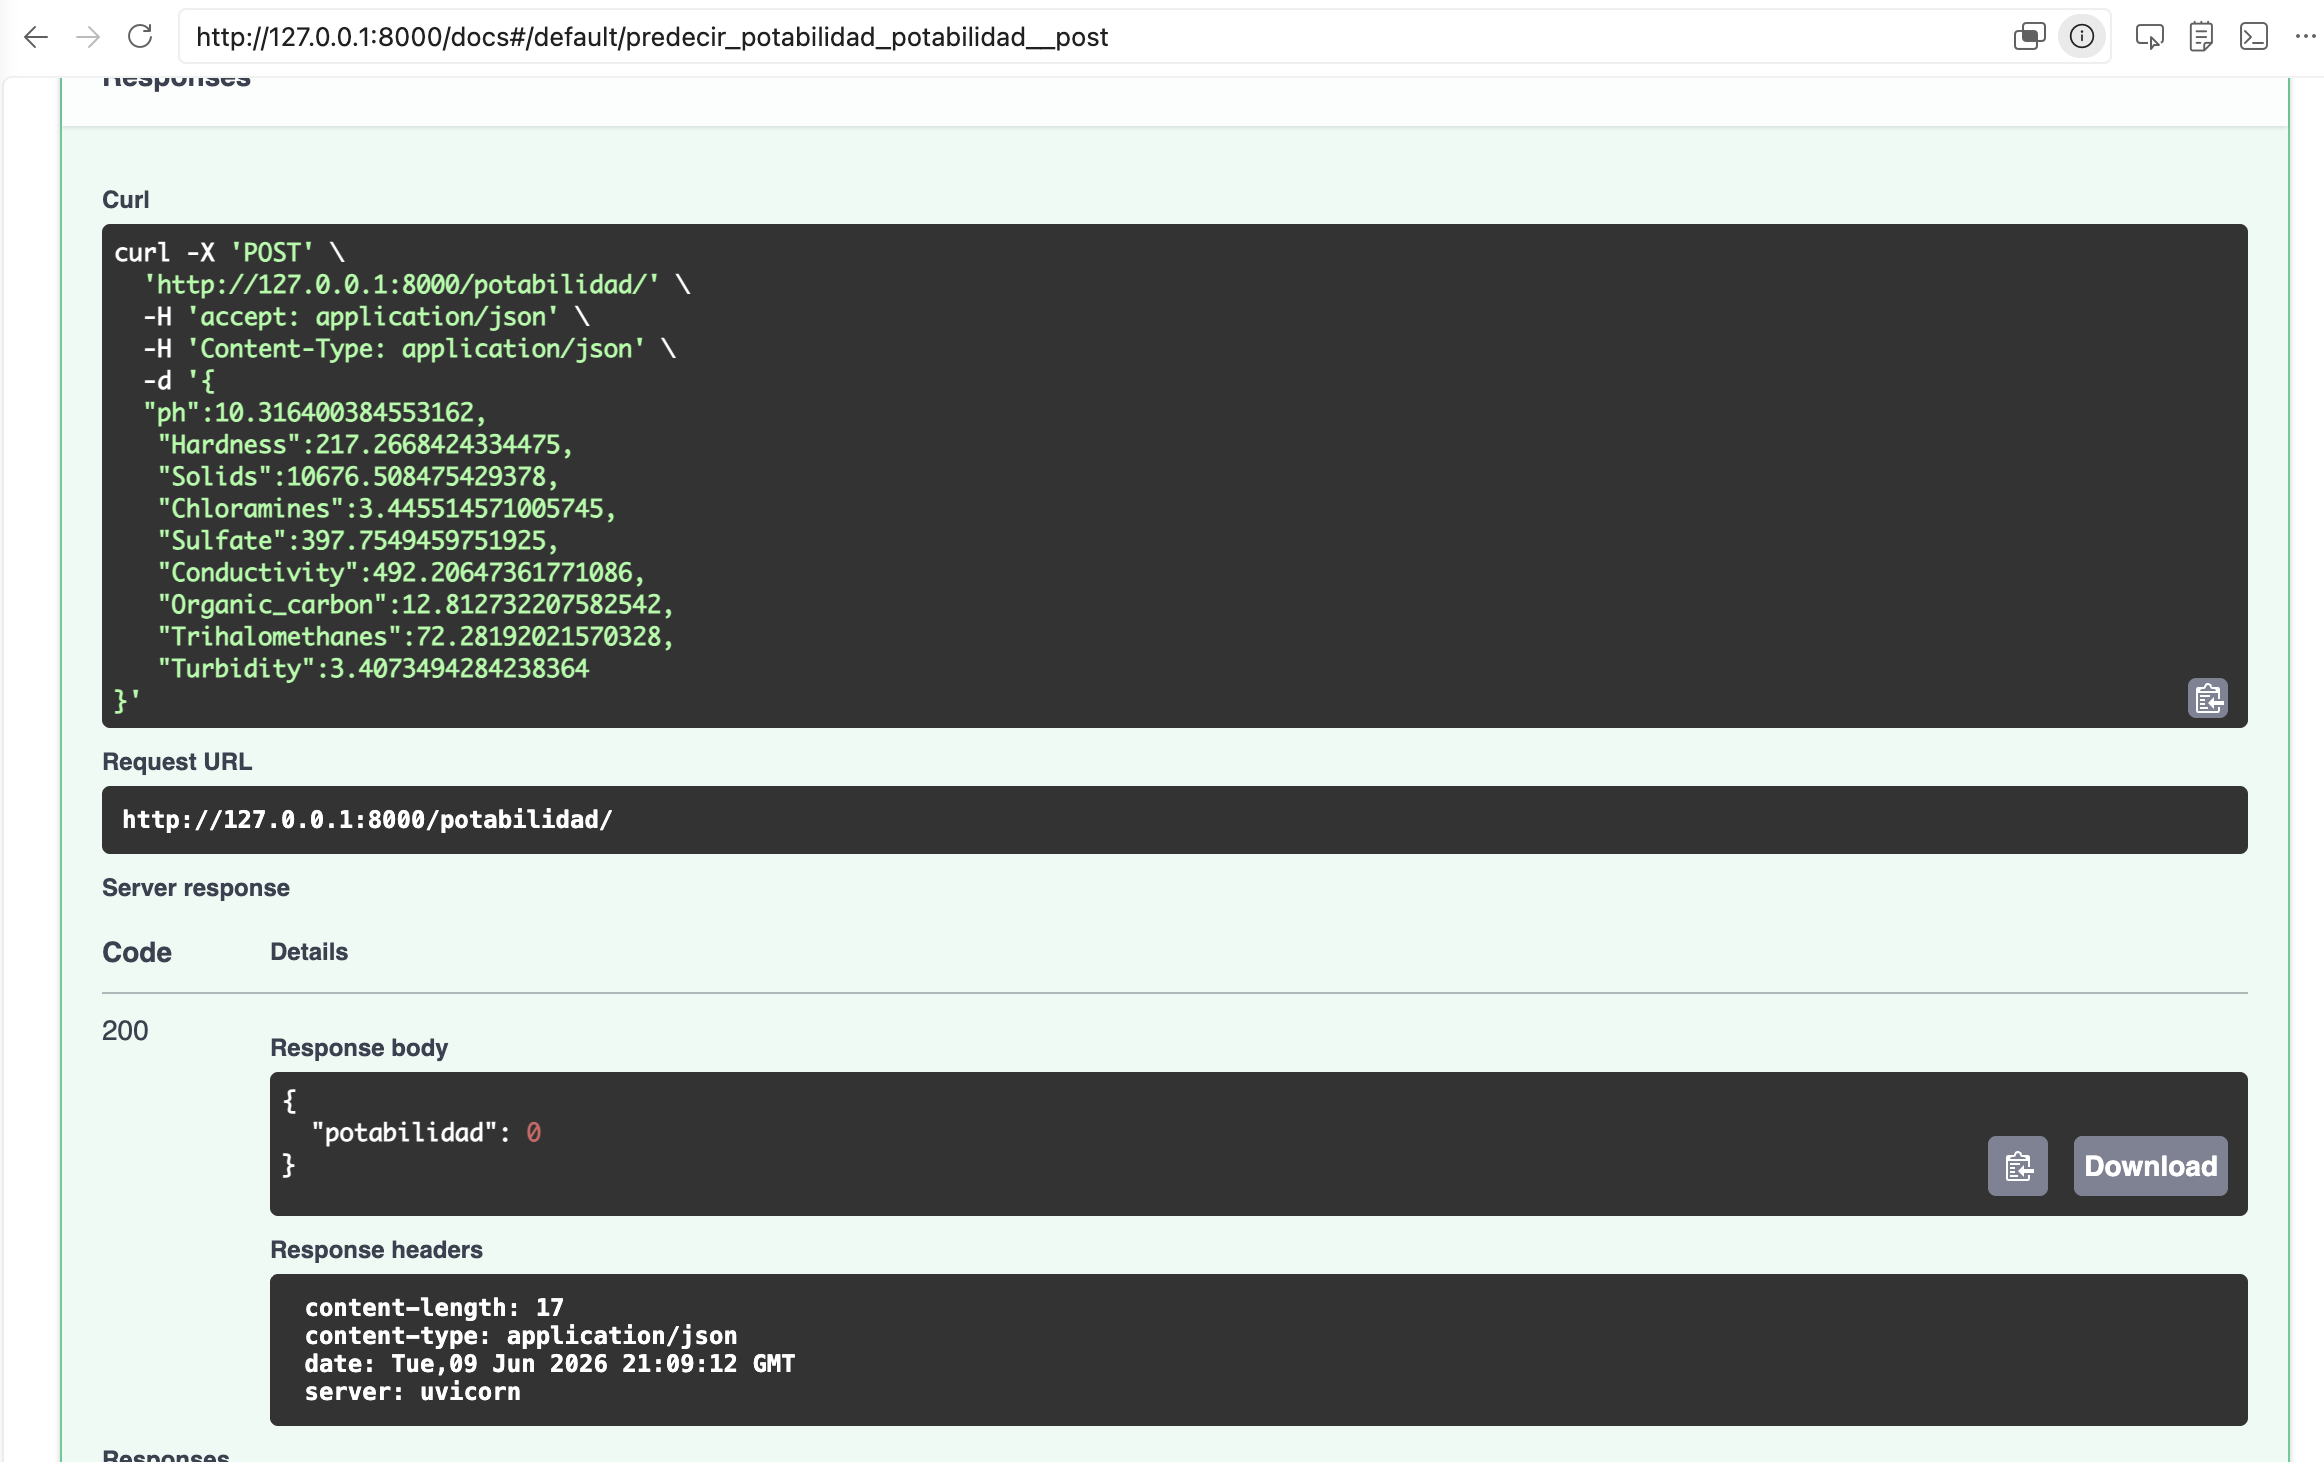

# **3. Docker (2 puntos)**

<div align="center">
  <img src="https://miro.medium.com/v2/resize:fit:1400/1*9rafh2W0rbRJIKJzqYc8yA.gif" width="500">
</div>

Tras el éxito de su aplicación web para generar la salida, Smapina le solicita que genere un contenedor para poder ejecutarla en cualquier computador de la empresa de agua potable.

## **3.1 Creación de Container (1 punto)**

Cree un Dockerfile que use una imagen base de Python, copie los archivos del proyecto e instale las dependencias desde un `requirements.txt`. Con esto, construya y ejecute el contenedor Docker para la API configurada anteriormente. Entregue el código fuente (incluyendo `main.py`, `requirements.txt`, y `Dockerfile`) y la imagen Docker de la aplicación. Para la dockerización, asegúrese de cumplir con los siguientes puntos:

1. **Generar un archivo `.dockerignore`** que ignore carpetas y archivos innecesarios dentro del contenedor.
2. **Configurar un volumen** que permita la persistencia de los datos en una ruta local del computador.
3. **Exponer el puerto** para acceder a la ruta de la API sin tener que entrar al contenedor directamente.
4. **Incluir imágenes en el notebook** que muestren la ejecución del contenedor y los resultados obtenidos.
5. **Revisar y comentar los recursos utilizados por el contenedor**. Analice si los contenedores son livianos en términos de recursos.

## **3.2 Preguntas de Smapina (1 punto)**
Tras haber experimentado con Docker, Smapina desea profundizar más en el tema y decide realizarle las siguientes consultas:

- ¿Cómo se diferencia Docker de una máquina virtual (VM)?
- ¿Cuál es la diferencia entre usar Docker y ejecutar la aplicación directamente en el sistema local?
- ¿Cómo asegura Docker la consistencia entre diferentes entornos de desarrollo y producción?
- ¿Cómo se gestionan los volúmenes en Docker para la persistencia de datos?
- ¿Qué son Dockerfile y docker-compose.yml, y cuál es su propósito?

# Conclusión

Éxito!
<div align="center">
  <img src="https://i.pinimg.com/originals/55/f5/fd/55f5fdc9455989f8caf7fca7f93bd96a.gif" width="500">
</div>